# Animal Text-Image Matching Pipeline

This notebook demonstrates the full pipeline:
1. **NER Model** - extracting animal entities from text
2. **Image Classifier** - classifying animals in images (ResNet-50)
3. **Full Pipeline** - matching text descriptions to images
4. **Normalization** - handling plurals and synonyms

## 1. Setup and Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from ner.inference import NERPredictor
from image_classifier.inference import ImageClassifier
from pipeline import AnimalPipeline, normalize_animal_name, KNOWN_CLASSES

%matplotlib inline

In [2]:
ner = NERPredictor()
classifier = ImageClassifier()
pipeline = AnimalPipeline(
    ner_model_path="models/ner",
    clf_model_path="models/image_classifier/best_model.pt",
    class_map_path="models/image_classifier/class_to_idx.json",
)

TEST_IMAGES = {p.stem.replace("test_", ""): str(p) for p in Path("test_data").glob("*")}
print("Available test images:", list(TEST_IMAGES.keys()))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Available test images: ['dog', 'elephant', 'squirrel']


## 2. NER Model Demo

Extract animal entities from various text inputs. The model resolves synonyms automatically (e.g. "kitty" → "cat").

In [3]:
ner_test_cases = [
    "There is a cow in the picture.",
    "I think that's a horse!",
    "Look at those puppies and kittens.",
    "Is that a butterfly or a spider?",
    "The weather is nice today.",
    "A majestic elephant roaming the savanna.",
    "Check out this cute kitten!",
]

print(f"{'Input Text':<50} {'Extracted Entities'}")
print("-" * 75)
for text in ner_test_cases:
    entities = ner.predict(text)
    print(f"{text:<50} {entities}")

Input Text                                         Extracted Entities
---------------------------------------------------------------------------
There is a cow in the picture.                     ['cow']
I think that's a horse!                            ['horse']
Look at those puppies and kittens.                 ['puppies', 'kittens']
Is that a butterfly or a spider?                   ['butterfly', 'spider']
The weather is nice today.                         []
A majestic elephant roaming the savanna.           ['elephant', 'savanna']
Check out this cute kitten!                        ['cat']


## 3. Image Classifier Demo

Classify test images using the fine-tuned ResNet-50. For each image we show the top-3 predictions with confidence bars.

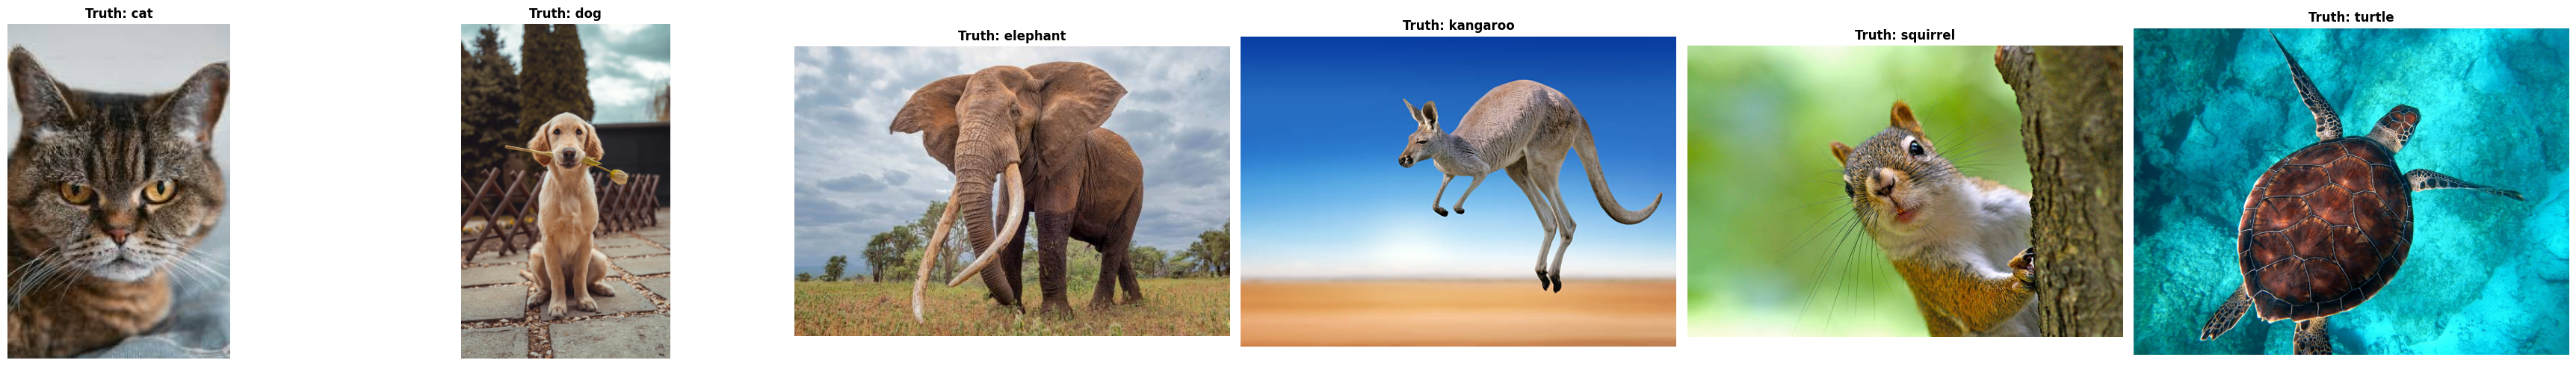

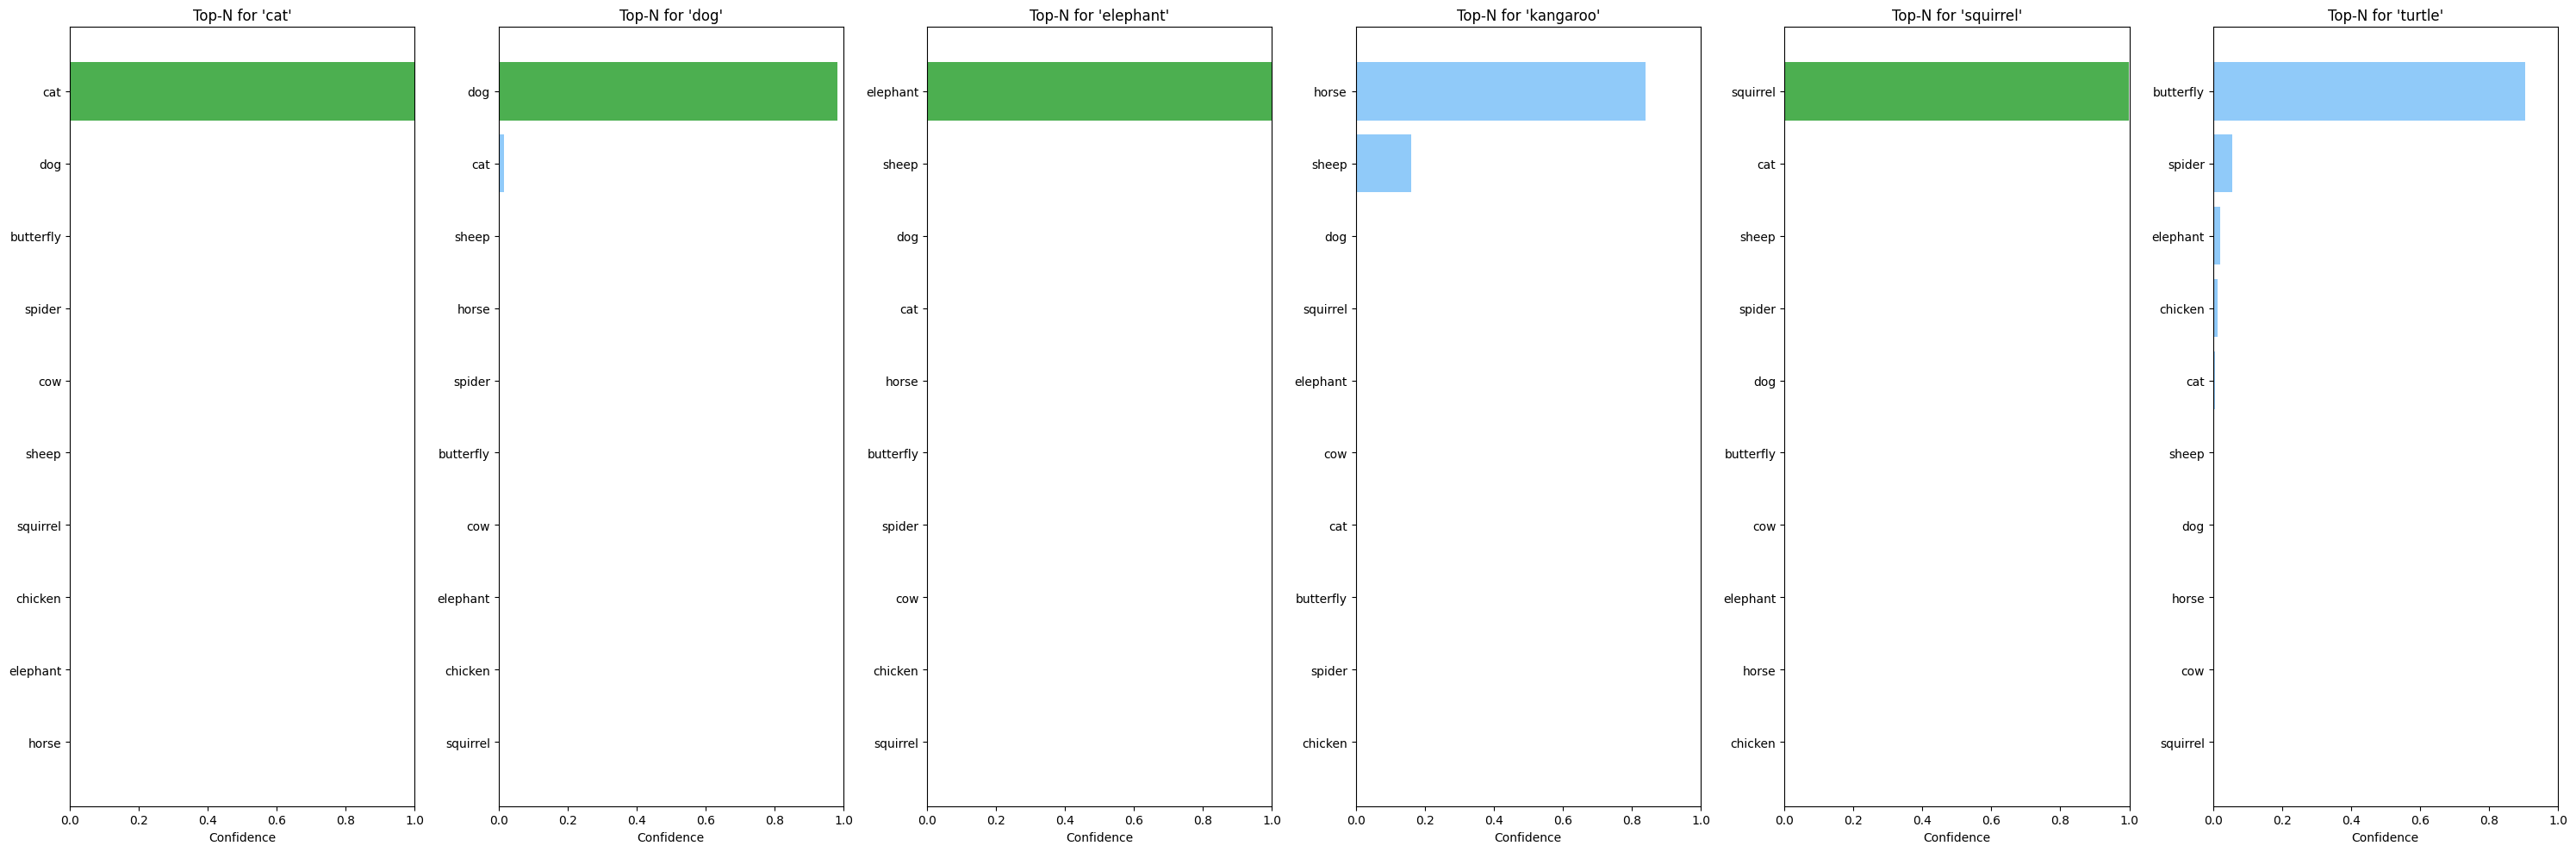

In [19]:
fig, axes = plt.subplots(1, len(TEST_IMAGES), figsize=(6 * len(TEST_IMAGES), 5))
if len(TEST_IMAGES) == 1:
    axes = [axes]

for ax, (label, img_path) in zip(axes, TEST_IMAGES.items()):
    img = Image.open(img_path).convert("RGB")
    preds = classifier.predict_from_pil(img, top_k=10)

    classes = [cls for cls, _ in preds]
    confs = [conf for _, conf in preds]

    ax.imshow(img)
    ax.set_title(f"Truth: {label}", fontsize=12, fontweight="bold")
    ax.axis("off")

fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(TEST_IMAGES), figsize=(5 * len(TEST_IMAGES), 10))
if len(TEST_IMAGES) == 1:
    axes = [axes]

for ax, (label, img_path) in zip(axes, TEST_IMAGES.items()):
    img = Image.open(img_path).convert("RGB")
    preds = classifier.predict_from_pil(img, top_k=10)

    classes = [cls for cls, _ in preds]
    confs = [conf for _, conf in preds]

    colors = ["#4CAF50" if cls == label else "#90CAF9" for cls in classes]
    ax.barh(classes[::-1], confs[::-1], color=colors[::-1])
    ax.set_xlim(0, 1)
    ax.set_xlabel("Confidence")
    ax.set_title(f"Top-N for '{label}'")

fig.tight_layout()
plt.show()

## 4. Full Pipeline Demo

Test the end-to-end pipeline: text -> NER -> image classification -> match.

### Positive cases (should match)

In [20]:
def img(name):
    return TEST_IMAGES.get(name, list(TEST_IMAGES.values())[0])

test_cases = [
    ("There is an elephant in the picture",  img("elephant"), True),
    ("I see a dog here",                     img("dog"),      True),
    ("Pretty sure that's a squirrel",        img("squirrel"), True),
    ("A cute cat sitting on the couch",      img("cat"),      True),
    ("There is a horse in the picture",      img("dog"),      False),
    ("Nice weather today",                   img("elephant"), False),
    ("Look at the puppy!",                   img("dog"),      True),
    ("I see some elephants",                 img("elephant"), True),
    ("Is that a dog or an elephant?",        img("elephant"), True),
    ("There is a penguin",                   img("elephant"), False),
    ("There is a kangaroo",                  img("kangaroo"), False),
    ("There is a turtle",                    img("turtle"),   False),
    ("I see an elephant",                    img("kangaroo"), False),
    ("I see a cat",                          img("turtle"),   False)
]

print(f"{'Text':<45} {'Image':<12} {'Result':<8} {'Expected':<10} {'Pass'}")
print("-" * 100)

for text, image_path, expected in test_cases:
    result = pipeline.run(text, image_path)
    match = result["match"]
    passed = match == expected
    image_label = Path(image_path).stem.replace("test_", "")
    status = "OK" if passed else "FAIL"
    print(f"{text:<45} {image_label:<12} {str(match):<8} {str(expected):<10} {status}")

Text                                          Image        Result   Expected   Pass
----------------------------------------------------------------------------------------------------
There is an elephant in the picture           elephant     True     True       OK
I see a dog here                              dog          True     True       OK
Pretty sure that's a squirrel                 squirrel     True     True       OK
A cute cat sitting on the couch               cat          True     True       OK
There is a horse in the picture               dog          False    False      OK
Nice weather today                            elephant     False    False      OK
Look at the puppy!                            dog          True     True       OK
I see some elephants                          elephant     True     True       OK
Is that a dog or an elephant?                 elephant     True     True       OK
There is a penguin                            elephant     False    False    

### Out-of-distribution images

Kangaroo and turtle are NOT in the 10 training classes. Let's see what the classifier maps them to and how confident it is.

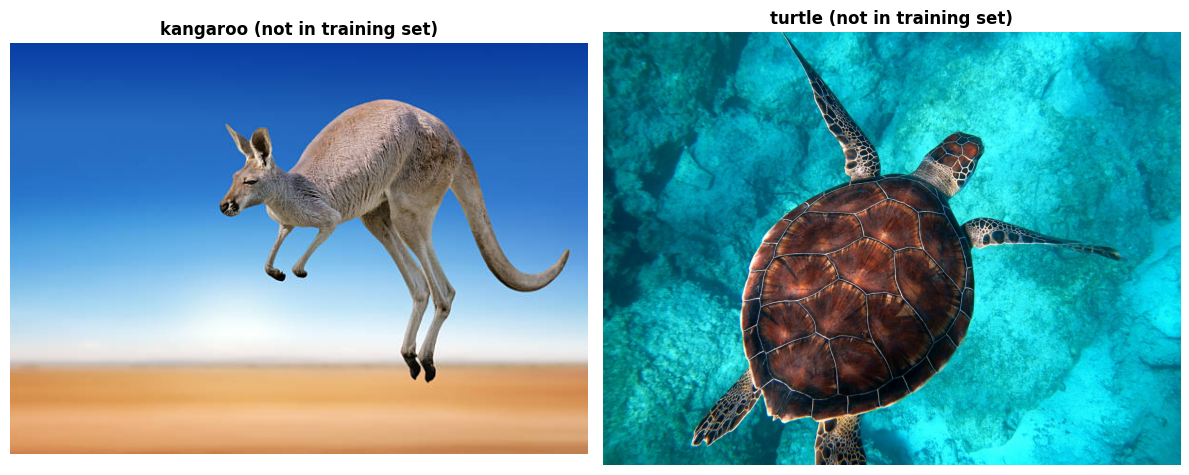

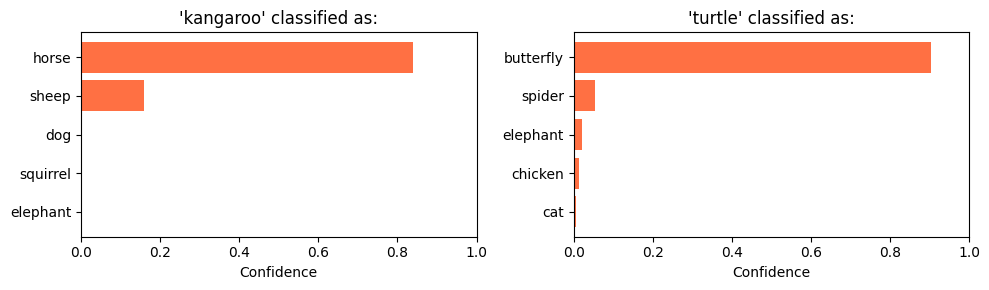

In [23]:
ood_images = {k: v for k, v in TEST_IMAGES.items() if k not in KNOWN_CLASSES}

if ood_images:
    fig, axes = plt.subplots(1, len(ood_images), figsize=(6 * len(ood_images), 5))
    if len(ood_images) == 1:
        axes = [axes]

    for ax, (label, img_path) in zip(axes, ood_images.items()):
        image = Image.open(img_path).convert("RGB")
        ax.imshow(image)
        ax.set_title(f"{label} (not in training set)", fontsize=12, fontweight="bold")
        ax.axis("off")

    fig.tight_layout()
    plt.show()

    # Show what the classifier thinks they are
    fig, axes = plt.subplots(1, len(ood_images), figsize=(5 * len(ood_images), 3))
    if len(ood_images) == 1:
        axes = [axes]

    for ax, (label, img_path) in zip(axes, ood_images.items()):
        image = Image.open(img_path).convert("RGB")
        preds = classifier.predict_from_pil(image, top_k=5)

        classes = [cls for cls, _ in preds]
        confs = [conf for _, conf in preds]

        ax.barh(classes[::-1], confs[::-1], color="#FF7043")
        ax.set_xlim(0, 1)
        ax.set_xlabel("Confidence")
        ax.set_title(f"'{label}' classified as:")

    fig.tight_layout()
    plt.show()
else:
    print("No out-of-distribution images found in test_data/.")

### Verbose output - detailed `pipeline.run()` result

In [22]:
result = pipeline.run(
    "There is an elephant in the picture",
    img("elephant"),
    verbose=True,
)
print("Full result dict:")
for k, v in result.items():
    print(f"  {k}: {v}")


Correct! Text mentions 'elephant' and the image is indeed a 'elephant'.

Full result dict:
  match: True
  image_prediction: elephant
  image_confidence: 0.9999986886978149
  reason: Text mentions 'elephant', image classified as 'elephant' (1.00)


## 6. Error Handling

In [24]:
try:
    pipeline.run("", img("elephant"))
except ValueError as e:
    print(f"ValueError: {e}")

ValueError: Text input cannot be empty


In [25]:
try:
    pipeline.run("There is a cow", "non_existent_image.jpg")
except FileNotFoundError as e:
    print(f"FileNotFoundError: {e}")

FileNotFoundError: Image not found: non_existent_image.jpg
